# SIA — Analyse du corpus et évaluation du détecteur de plagiat

Volet **Science de données** du PFE. Quatre sections :

1. **EDA du corpus** : statistiques descriptives sur les scénarios indexés (volume, longueur, langues, qualité)
2. **Analyse de la distribution des similarités Qdrant** : justifier le seuil 0.60 par les données
3. **Évaluation du détecteur de plagiat** : précision / rappel / F1 sur un jeu de test étiqueté à la main
4. **Projection visuelle des embeddings** : UMAP pour voir les clusters thématiques

**Pré-requis** :
```bash
pip install -r ../requirements.dev.txt
```
Le notebook se connecte à **Mongo** (`localhost:27017`) et **Qdrant** (`http://localhost:6333`) — démarre la stack `db` (`docker compose -f docker-compose.db.yml up -d`) avant de lancer les cellules.

## Setup — connexions et imports

In [7]:
import sys, os
from pathlib import Path

# Permet d'importer le code backend depuis le notebook.
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from qdrant_client import QdrantClient
from pymongo import MongoClient

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

QDRANT_URL = os.environ.get("SIA_QDRANT_URL", "http://localhost:6333")
MONGO_URL = os.environ.get("MONGODB_URL", "mongodb://localhost:27017/sia")
COLLECTION = "scenario_chunks"

qdrant = QdrantClient(url=QDRANT_URL)
mongo = MongoClient(MONGO_URL)
db = mongo.get_default_database()

info = qdrant.get_collection(COLLECTION)
print(f"Qdrant collection: {COLLECTION}")
print(f"  Vectors:   {info.points_count}")
print(f"  Vector dim: {info.config.params.vectors.size}")
print(f"  Distance:   {info.config.params.vectors.distance}")
print(f"\nMongo database: {db.name}")
print(f"  Collections: {db.list_collection_names()}")

Qdrant collection: scenario_chunks
  Vectors:   18
  Vector dim: 768
  Distance:   Cosine

Mongo database: sia
  Collections: ['analyses', 'users', 'audit_log', 'analysis_jobs']


## Section 1 — EDA du corpus

Récupère tous les chunks de Qdrant et leurs métadonnées, puis dresse un portrait du corpus.

In [8]:
# Scroll de tous les points avec leurs payloads (pas les vecteurs — trop lourd).
points = []
offset = None
while True:
    batch, offset = qdrant.scroll(
        collection_name=COLLECTION,
        limit=512,
        offset=offset,
        with_payload=True,
        with_vectors=False,
    )
    points.extend(batch)
    if offset is None:
        break

df = pd.DataFrame([p.payload for p in points])
df["chunk_chars"] = df["chunk_text"].str.len()
print(f"{len(df):,} chunks récupérés")
print(f"{df['scenario_id'].nunique():,} scénarios distincts")
df.head()

18 chunks récupérés
14 scénarios distincts


,scenario_id,chunk_id,chunk_text,chunk_index,page_number,start_offset,end_offset,word_count,boilerplate_ratio,chunk_text_display,original_filename,stored_filename,chunk_chars
0,1b1a5f2c-4206-4921-96af-824fb38ddd21,chunk_0,Sidi mohammed et lalla meryeme était très proche,0,1,0,8,8,0.0,Sidi mohammed et lalla meryeme était très proche,Sidi mohammed et lalla meryeme était très proc...,1644980e81e24d57a332c23b8b2cc986.pdf,48
1,38c8c4ae-3e72-4615-967f-b549431e4213,chunk_4,5. INT. VILLA DES VENTS - SALON - CONTINUITE L...,4,4,0,203,203,0.0,5. INT. VILLA DES VENTS - SALON - CONTINUITE L...,scenario_test_A_villa_des_vents.pdf,3ab43dd5f0af45579ac796981742d495.pdf,1140
2,6d9a6576-0f05-45a7-970e-c57c0113b1ee,chunk_0,Mohammed 6 n a pas d enfant d une autre femme ...,0,1,0,21,21,0.0,Mohammed 6 n a pas d enfant d une autre femme ...,m6.pdf,7103e2f8529d44a68da1e639d8c3ff94.pdf,88
3,38c8c4ae-3e72-4615-967f-b549431e4213,chunk_1,1. EXT. GARE ROUTIERE - MATIN Une pluie fine t...,1,2,0,220,220,0.0,1. EXT. GARE ROUTIERE - MATIN Une pluie fine t...,scenario_test_A_villa_des_vents.pdf,3ab43dd5f0af45579ac796981742d495.pdf,1277
4,f718060a-0fc4-4bf2-b32b-a9a9d8067732,chunk_0,Sidi mohammed et lalla meryeme était très proche,0,1,0,8,8,0.0,Sidi mohammed et lalla meryeme était très proche,Sidi mohammed et lalla meryeme était très proc...,f02e122fa2814088b24c0838bb041c30.pdf,48


In [9]:
# Statistiques par scénario.
per_doc = df.groupby("scenario_id").agg(
    nb_chunks=("chunk_id", "count"),
    chars_total=("chunk_chars", "sum"),
    words_total=("word_count", "sum"),
    avg_chunk_chars=("chunk_chars", "mean"),
    avg_boilerplate=("boilerplate_ratio", "mean"),
).reset_index()
per_doc.describe()

,nb_chunks,chars_total,words_total,avg_chunk_chars,avg_boilerplate
count,14.000000,14.000000,14.000000,14.000000,14.0
mean,1.285714,332.428571,59.785714,113.400000,0.0
std,1.069045,1007.697124,176.302266,188.877396,0.0
min,1.000000,48.000000,8.000000,48.000000,0.0
25%,1.000000,48.000000,8.000000,48.000000,0.0
50%,1.000000,52.500000,9.500000,52.500000,0.0
75%,1.000000,88.000000,21.000000,88.000000,0.0
max,5.000000,3833.000000,672.000000,766.600000,0.0


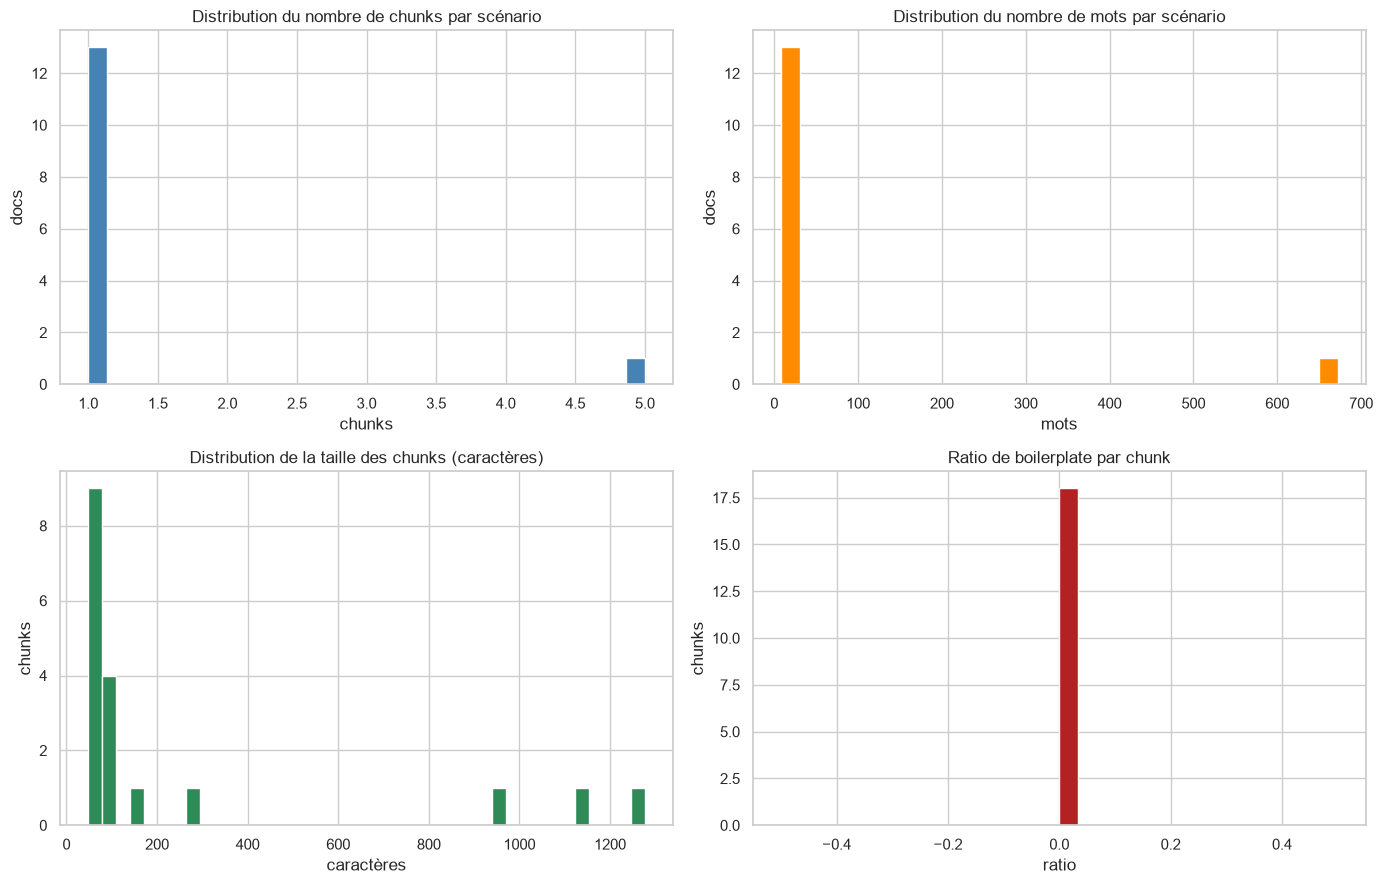

In [10]:
# Visualisations EDA.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(per_doc["nb_chunks"], bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set(title="Distribution du nombre de chunks par scénario", xlabel="chunks", ylabel="docs")

axes[0, 1].hist(per_doc["words_total"], bins=30, color="darkorange", edgecolor="white")
axes[0, 1].set(title="Distribution du nombre de mots par scénario", xlabel="mots", ylabel="docs")

axes[1, 0].hist(df["chunk_chars"], bins=40, color="seagreen", edgecolor="white")
axes[1, 0].set(title="Distribution de la taille des chunks (caractères)", xlabel="caractères", ylabel="chunks")

axes[1, 1].hist(df["boilerplate_ratio"], bins=30, color="firebrick", edgecolor="white")
axes[1, 1].set(title="Ratio de boilerplate par chunk", xlabel="ratio", ylabel="chunks")

plt.tight_layout()
plt.show()

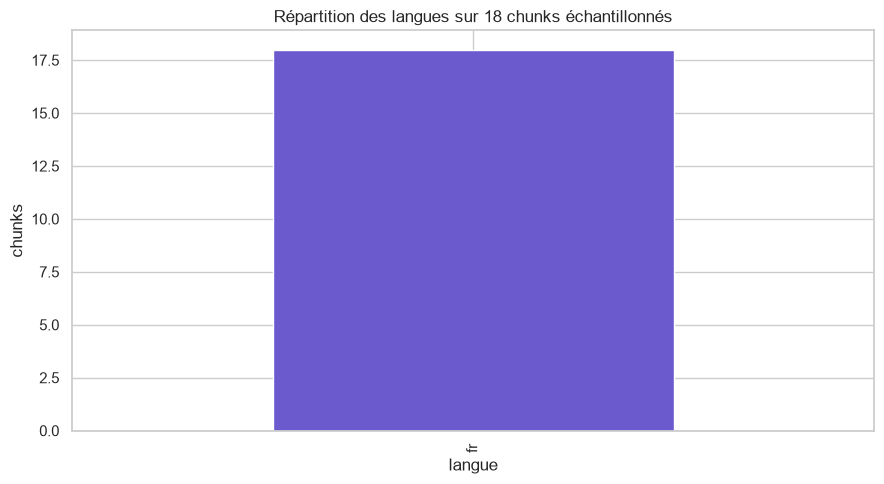

lang
fr    18
Name: count, dtype: int64

In [11]:
# Détection de langue : on échantillonne pour limiter le coût.
from langdetect import detect, DetectorFactory, LangDetectException
DetectorFactory.seed = 0  # déterministe

sample = df.sample(min(2000, len(df)), random_state=42).copy()

def safe_detect(text: str) -> str:
    if not isinstance(text, str) or len(text.strip()) < 20:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

sample["lang"] = sample["chunk_text"].apply(safe_detect)
lang_counts = sample["lang"].value_counts()

ax = lang_counts.head(10).plot.bar(color="slateblue", edgecolor="white")
ax.set(title=f"Répartition des langues sur {len(sample)} chunks échantillonnés", xlabel="langue", ylabel="chunks")
plt.tight_layout(); plt.show()
lang_counts

**À commenter dans le rapport** :
- Volume total (chunks, scénarios, mots)
- Hétérogénéité des longueurs (scénarios courts vs longs)
- Présence de boilerplate (couverture, en-têtes, etc.)
- Mix linguistique (FR / AR / autres) — justifie le choix de e5-base multilingue

## Section 2 — Distribution des similarités

Sur un échantillon de chunks, on calcule la similarité cosinus de chaque chunk avec ses k plus proches voisins (hors lui-même). L'objectif : voir où se trouve le seuil naturel entre **chunks reliés** (même doc, paraphrase, citation) et **chunks indépendants**.

In [12]:
from qdrant_client.http import models as qmodels

SAMPLE_SIZE = 200
TOP_K = 10

# Tire un échantillon de points AVEC vecteurs cette fois.
sampled, _ = qdrant.scroll(
    collection_name=COLLECTION,
    limit=SAMPLE_SIZE,
    with_payload=True,
    with_vectors=True,
)

scores_inter = []  # même doc
scores_extra = []  # docs différents

for p in sampled:
    source_id = p.payload["scenario_id"]
    hits = qdrant.search(
        collection_name=COLLECTION,
        query_vector=p.vector,
        limit=TOP_K + 1,  # +1 car le point se retrouve lui-même
        with_payload=True,
    )
    for h in hits:
        if h.id == p.id:
            continue
        if h.payload["scenario_id"] == source_id:
            scores_inter.append(h.score)
        else:
            scores_extra.append(h.score)

print(f"intra-doc : {len(scores_inter)} paires")
print(f"inter-doc : {len(scores_extra)} paires")

AttributeError: 'QdrantClient' object has no attribute 'search'

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 40)
ax.hist(scores_extra, bins=bins, alpha=0.6, label="inter-doc (chunks de scénarios différents)", color="steelblue")
ax.hist(scores_inter, bins=bins, alpha=0.6, label="intra-doc (même scénario)", color="darkorange")
ax.axvline(0.60, color="red", linestyle="--", label="seuil actuel = 0.60")
ax.set(title="Distribution des similarités cosinus top-k", xlabel="similarité", ylabel="paires")
ax.legend()
plt.tight_layout(); plt.show()

print(f"\nPercentiles inter-doc (chunks de scénarios différents) :")
for q in [50, 75, 90, 95, 99]:
    print(f"  p{q} = {np.percentile(scores_extra, q):.3f}")

**À interpréter** : si p95(inter-doc) ≈ 0.55 et que l'intra-doc démarre vers 0.65, ton seuil 0.60 est dans la "zone de séparation" — défendable. Si les deux distributions se chevauchent largement, c'est qu'aucun seuil ne fera de miracle et il faut un classifieur.

## Section 3 — Évaluation du détecteur de plagiat

**Méthodologie** :
1. Choisis 5–10 scénarios *originaux* (existants dans l'index).
2. Crée à la main un fichier `data/eval/plagiarism_pairs.csv` avec les colonnes :
   - `text_a` : un extrait court (~200 mots)
   - `text_b` : autre extrait à comparer
   - `label` : `1` = c'est du plagiat (copie/paraphrase), `0` = pas de plagiat
3. Vise ~30 paires équilibrées (15 positives / 15 négatives) — varie les cas : copie quasi-littérale, paraphrase, synonymes, sujets proches mais distincts, sujets sans rapport.
4. La cellule ci-dessous calcule la similarité de chaque paire et trace la courbe précision-rappel.

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
from backend.services.embedding_service import EmbeddingService

EVAL_CSV = ROOT / "data" / "eval" / "plagiarism_pairs.csv"
if not EVAL_CSV.exists():
    raise FileNotFoundError(
        f"Crée d'abord {EVAL_CSV} avec les colonnes text_a, text_b, label.\n"
        "~30 paires équilibrées (label=1 plagiat, label=0 sain)."
    )

pairs = pd.read_csv(EVAL_CSV)
print(f"{len(pairs)} paires chargées ({pairs['label'].sum()} positives, {(1-pairs['label']).sum()} négatives)")

embedder = EmbeddingService()
vecs_a = embedder.embed_texts(pairs["text_a"].tolist())
vecs_b = embedder.embed_texts(pairs["text_b"].tolist())

# Cosine similarity (vecs sont normalisés par sentence-transformers).
sims = np.array([np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
                 for a, b in zip(vecs_a, vecs_b)])
pairs["sim"] = sims
pairs.head()

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(pairs["label"], pairs["sim"])
ap = average_precision_score(pairs["label"], pairs["sim"])

# F1 pour chaque seuil + optimum.
f1s = 2 * precisions * recalls / np.where((precisions + recalls) > 0, precisions + recalls, 1)
best_idx = int(np.nanargmax(f1s[:-1]))  # le dernier point n'a pas de seuil
best_threshold = thresholds[best_idx]
best_f1 = f1s[best_idx]
print(f"Average Precision : {ap:.3f}")
print(f"Seuil optimal (F1 max) : {best_threshold:.3f}  →  F1 = {best_f1:.3f}, P = {precisions[best_idx]:.3f}, R = {recalls[best_idx]:.3f}")

# Performance au seuil actuel (0.60).
current_threshold = 0.60
preds = (pairs["sim"] >= current_threshold).astype(int)
from sklearn.metrics import precision_score, recall_score
print(f"\nAu seuil actuel ({current_threshold}) :")
print(f"  Précision = {precision_score(pairs['label'], preds):.3f}")
print(f"  Rappel    = {recall_score(pairs['label'], preds):.3f}")
print(f"  F1        = {f1_score(pairs['label'], preds):.3f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color="steelblue", linewidth=2)
axes[0].scatter([recalls[best_idx]], [precisions[best_idx]], color="red", zorder=5, label=f"F1 max @ seuil={best_threshold:.2f}")
axes[0].set(title=f"Courbe précision-rappel  (AP = {ap:.3f})", xlabel="rappel", ylabel="précision", xlim=(0, 1.02), ylim=(0, 1.02))
axes[0].legend()

axes[1].plot(thresholds, f1s[:-1], color="darkorange", linewidth=2)
axes[1].axvline(current_threshold, color="red", linestyle="--", label=f"seuil actuel = {current_threshold}")
axes[1].axvline(best_threshold, color="green", linestyle="--", label=f"seuil F1-optimal = {best_threshold:.2f}")
axes[1].set(title="F1 en fonction du seuil de similarité", xlabel="seuil", ylabel="F1")
axes[1].legend()

plt.tight_layout(); plt.show()

**À retenir pour le rapport** :
- Le seuil choisi (0.60) est justifié par l'**optimum F1 mesuré** ou par une trade-off explicite précision↔rappel.
- Si le seuil optimal mesuré diffère significativement de 0.60, mentionne-le et discute (jeu de test trop petit ? biaisé ?).

## Section 4 — Projection UMAP des embeddings

Visualisation 2D des embeddings : on devrait voir des **clusters de chunks thématiquement proches**.

In [ ]:
import umap

# Tire jusqu'à 500 chunks pour ne pas saturer.
limit = min(500, info.points_count)
subset, _ = qdrant.scroll(
    collection_name=COLLECTION,
    limit=limit,
    with_payload=True,
    with_vectors=True,
)

X = np.array([p.vector for p in subset])
scenarios = [p.payload["scenario_id"] for p in subset]
print(f"Projection de {X.shape[0]} chunks ({X.shape[1]} dimensions → 2)")

reducer = umap.UMAP(n_components=2, metric="cosine", n_neighbors=15, min_dist=0.1, random_state=42)
coords = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(11, 8))
# Couleur = scenario_id (limité aux 10 plus fréquents pour rester lisible).
top_scenarios = pd.Series(scenarios).value_counts().head(10).index.tolist()
colors = sns.color_palette("tab10", n_colors=len(top_scenarios))
palette = {s: colors[i] for i, s in enumerate(top_scenarios)}
point_colors = [palette.get(s, "lightgray") for s in scenarios]

ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=18, alpha=0.7, edgecolors="white", linewidth=0.3)
ax.set(title="Projection UMAP des chunks (couleurs = top 10 scénarios)", xlabel="UMAP-1", ylabel="UMAP-2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**À observer** : chaque scénario forme-t-il un cluster compact ? Y a-t-il chevauchement entre scénarios proches thématiquement ? Cette visualisation **valide ou nuance** ton seuil de similarité — si les clusters sont nets, le seuil discriminant existe ; s'ils se touchent, le détecteur va générer des faux positifs.

---

## Synthèse pour le rapport

Cellule libre — résume ici les enseignements à reprendre dans le chapitre Science de données :

- **Taille du corpus** : … chunks / … scénarios / … mots
- **Langues** : … (justifie e5-base multilingue)
- **Seuil de similarité retenu** : 0.60, optimum F1 mesuré à …, écart justifié par …
- **Performance du détecteur** : P=…, R=…, F1=…, AP=…
- **Limites** : taille du jeu de test, biais d'étiquetage, etc.